### Exercise 2 (Mapping Wind Power Generation, 20 Points)
Ahmet Meriç Kızıltaş

In [1]:
mamba install -c conda-forge geopandas pyogrio

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, geopandas, pyogrio
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.3065 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.5.20  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.7      pyhd8ed1ab_0         conda-forge
+ folium              0.20.0     pyhd8ed1ab_0         conda-forge
+ geopandas           1.1.3      pyhd8ed1ab_0         conda-forge
+ geopandas-base      1.1.3      pyha770c72_0         conda-forge
+ geos                3.14.1     hb88d4a0_1           emscripten-forge-4x
+ idna                3.17       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ libgdal-core        3.12.4 

**a)** *Create a plot that shows the administrative areas of Germany. (2P)*

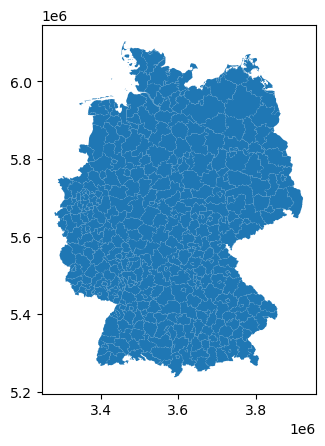

In [10]:
import geopandas
import pyogrio

gdf = geopandas.read_file("VG1000_KRS.dbf")

import matplotlib.pyplot as plt

gdf.plot()
plt.show()

**b)** *Find Bonn in the dataset and plot the polygon for Bonn. (2P)*


In [17]:
print(gdf.columns)

Index(['ADE', 'GF', 'BSG', 'ARS', 'AGS', 'SDV_ARS', 'GEN', 'BEZ', 'IBZ', 'BEM',
       'NBD', 'SN_L', 'SN_R', 'SN_K', 'SN_V1', 'SN_V2', 'SN_G', 'FK_S3',
       'NUTS', 'ARS_0', 'AGS_0', 'WSK', 'DEBKG_ID', 'geometry'],
      dtype='str')


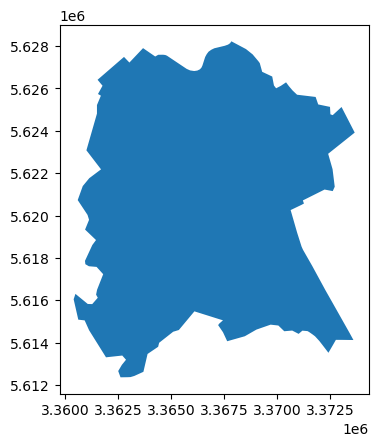

In [28]:
bonn = gdf[gdf["GEN"] == "Bonn"]
bonn.plot()
plt.show()

**c)** *Add a marker at the location of Bonn to your administrative map of Germany. (2P)*
Hint: You somehow need to turn the polygon into a single point.

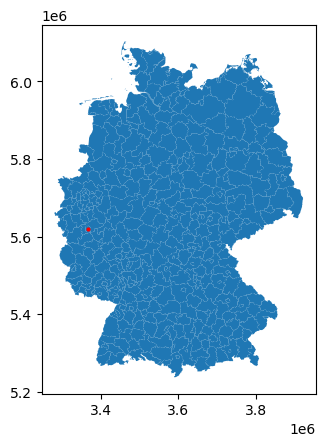

In [39]:
bonn["centroid"] = bonn.geometry.centroid
gdf.plot()
plt.scatter(bonn["centroid"].x, bonn["centroid"].y, color = "red", s = 4)
plt.show()

**d)** *Please calculate the accumulated power generation for each administrative district and plant type.
(2P)*


In [95]:
import pandas as pd

df = pd.read_csv("power_generation.csv", encoding="latin1")
df = df.groupby(["energyType", "district"])["netRatePower"].sum().reset_index()

**e)** *Both datasets use the same IDs for the administrative districts. Merge the two datasets so that
the entries are correctly matched by administrative districts for the plant type wind. (4P)*

In [104]:
wind = df[df["energyType"]== "wind"]
wind["district"] = (wind["district"]/1000).astype(int)
wind["district"] = wind["district"].astype("Int64")
gdf["ARS"] = gdf["ARS"].astype("Int64")
print(wind)

     energyType  district  netRatePower
3223       wind      1001       73310.0
3224       wind      1002          75.0
3225       wind      1003       14650.0
3226       wind      1051     2494025.8
3227       wind      1053      137075.0
...         ...       ...           ...
3549       wind     16073        9250.0
3550       wind     16074      150843.0
3551       wind     16075       55107.0
3552       wind     16076       74327.0
3553       wind     16077      116525.0

[331 rows x 3 columns]


In [107]:
mapping = wind.set_index("district")["netRatePower"]

gdf["wind"] = gdf["ARS"].map(mapping)
gdf["wind"] = gdf["wind"].fillna(0)

**f)** *Plot a map that encodes the generated wind power for each administrative district. Include a
legend that tells the reader how to interpret the colors. (2P)*


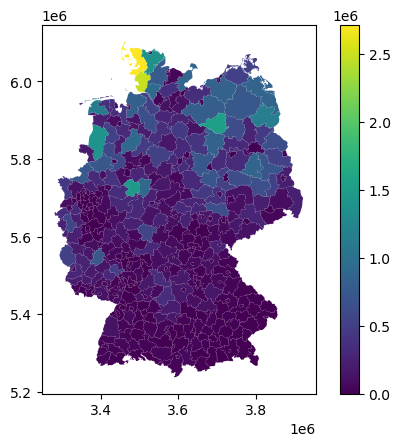

In [110]:
gdf.plot(column="wind", legend=True, cmap="viridis")

plt.show()

**g)** *Currently, the colormap is not very meaningful because there are two districts producing much*
more power than all other districts. Recreate the plot with optimized utilization of the colorscale
range by clipping the upper bound. (2P)*


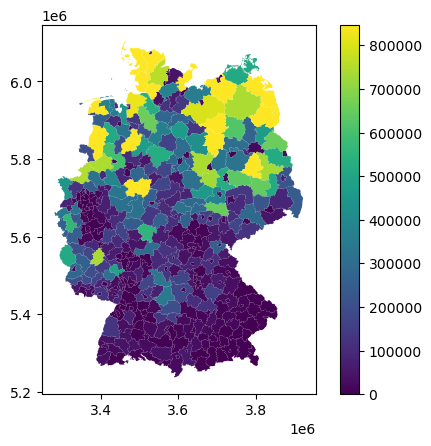

In [112]:
vmax = gdf["wind"].quantile(0.95)

gdf.plot(column="wind",cmap="viridis", legend=True,vmin=0,vmax=vmax)
plt.show()

**h)** *Employ geopandas to compute the size of each administrative district in Germany, and create a
plot of the generated wind power, normalized by area. (3P)*


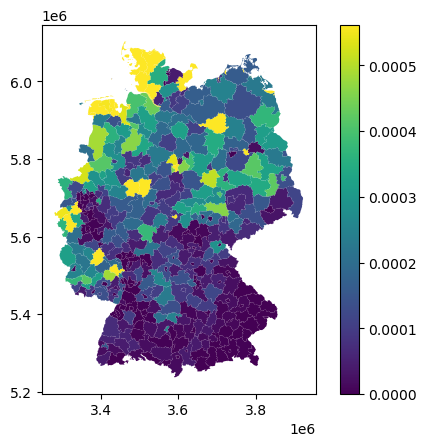

In [119]:
gdf["surface"] = gdf.geometry.area
gdf["wind_density"] = gdf["wind"] / gdf["surface"]

vmax = gdf["wind_density"].quantile(0.90)

gdf.plot(column="wind_density", legend=True, cmap="viridis", vmax = vmax, vmin = 0)

plt.show()

**i)** *What pattern do you observe in the distribution of wind power generation across Germany? (1P)*

We observe generally a particularly high generation in the counties that border the Nothern Sea. Also, we see a  high generation in some western and eastern counties. Almost no wind power is generated in the south and in the Rhein valley.